# Early Exploration

In [ ]:
using DifferentialEquations
using Plots

c1 = 1.0
c2 = 0.5

L = 1.0
Nx = 200

dx = L/(Nx-1)

x = range(0, L, length=Nx)

# for plotting
θ = π .* (x ./ L)

# Initial conditions
u0 = ones(Nx)
v0 = ones(Nx)

Y0 = vcat(u0, v0)

function coupled_transport!(dY, Y, p, t)
    c1, c2, dx, Nx = p

    u = @view Y[1:Nx]
    v = @view Y[Nx+1:2Nx]

    du = @view dY[1:Nx]
    dv = @view dY[Nx+1:2Nx]

    # Coupled boundary conditions
    uL = 0.85*v[end]
    vL = 1.15*u[end]

    # Left boundary points
    du[1] = -c1 * (u[1] - uL)/dx
    dv[1] = -c2 * (v[1] - vL)/dx

    # Interior
    for i in 2:Nx
        du[i] = -c1 * (u[i] - u[i-1])/dx
        dv[i] = -c2 * (v[i] - v[i-1])/dx
    end
end

tspan = (0.0, 8.0)

prob = ODEProblem(
    coupled_transport!,
    Y0,
    tspan,
    (c1, c2, dx, Nx)
)

sol = solve(prob, Tsit5(), saveat=0.01)

In [ ]:
θ = π * x ./ L
plot(
    θ, u0,
    label = "u₀",
    proj = :polar,
    title = "Initial conditions",
    xticks = (0:pi/4.0:2*pi, ["0","\\pi/4", "3", "4", "5", "6", "7", "8"])
    #xticks = (LinRange(0, 2*pi, steps=8)),
)
plot!(
    θ.+pi, v0,
    label = "v₀",
)

In [ ]:
energy = [
    sum(u[1:Nx].^2 .+ u[Nx+1:end].^2)*dx
    for u in sol.u
]

plot(sol.t, energy,
    xlabel="t",
    ylabel="Population",
    title="Population in Transit vs Time",
    linewidth=3)

In [ ]:
anim = @animate for k in 1:length(sol.t)

    Puv = sol.u[k][1:Nx]
    Pvu = sol.u[k][Nx+1:2Nx]


    plot(
        θ, Puv,
        label="uv",
        proj = :polar,
        legend=:topright,
        title="JP Coupled transport on a ring\nt=$(round(sol.t[k], digits=2))"
    )
    plot!(
        θ.+pi, Pvu,
        label="vu",
    )

end

gif(anim, "jp_ring_transport.gif", fps=25)

# Using WorldCupTraffic.jl

In [1]:
using Pkg
using Plots
Pkg.activate("WorldCupTraffic")
#Pkg.instantiate()
using DifferentialEquations

  Activating project at `~/doc/edu/2026/Spring/math540/project/WorldCupTraffic`


In [2]:
using WorldCupTraffic

[ Info: Precompiling WorldCupTraffic [5a82a2da-1bb1-45fe-a8ef-729ac6c10b6d](cache misses: include_dependency fsize change (1))
[ Info: Precompiling WorldCupTraffic [5a82a2da-1bb1-45fe-a8ef-729ac6c10b6d] (cache misses: include_dependency fsize change (2))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


In [3]:
function build_const_v(v)
    return (x,t,P,Astart,Aend) -> v
end
function constant_v(x,t,P, Astart, Aend)
    return 1
end
function sin2_v(x,t,P,Astart,Aend)
    return sin(t)^2
end;

In [4]:
ns = (100,100)
Ls = (10,10)
boundary_conds = (t->0,t->0) # total conservation (add 0 flux)

(var"#4#5"(), var"#6#7"())

In [10]:
prob = TwoNodeSystem(
    n1=ns[1],
    n2=ns[2],
    L1=Ls[1],
    L2=Ls[2],
    init_P1=[ones(25);zeros(25);ones(25);zeros(25)],
    init_P2=zeros(100),
    boundary_conds=boundary_conds,
    velocity_1=build_const_v(1.5),
    velocity_2=build_const_v(1.75),
    attraction_1=(t)->1,
    attraction_2=(t)->1,
    tspan=(0,1000)
)

ODEProblem with uType Vector{Float64} and tType Int64. In-place: true
Non-trivial mass matrix: false
timespan: (0, 1000)
u0: 200-element Vector{Float64}:
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 ⋮
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0

In [11]:
sol = solve(prob, Tsit5());

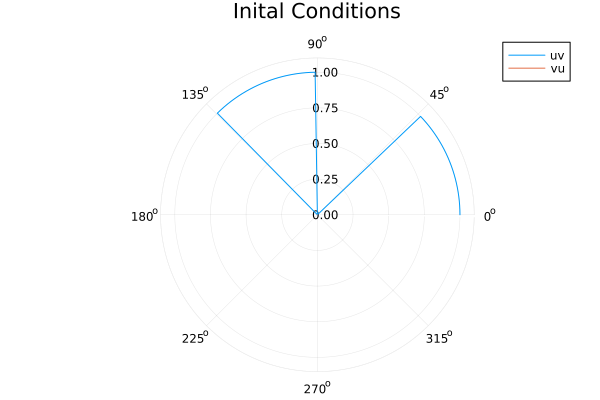

In [12]:
display(TwoNodePlot(ns, Ls, sol.u[1][1:ns[1]], sol.u[1][ns[1]+1:end], title="Inital Conditions"))

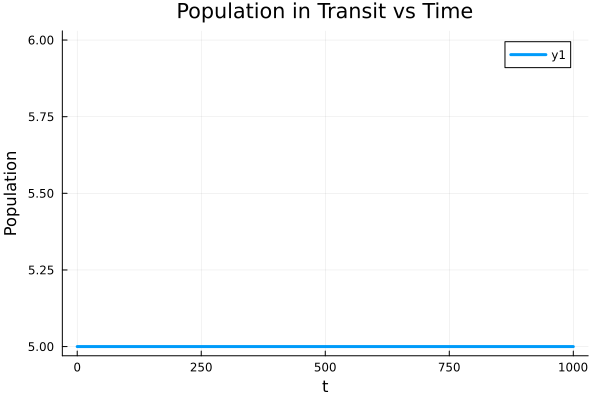

In [13]:
population = [
    Ls[1]/ns[1] * sum(u[1:ns[1]]) + Ls[2]/ns[2] * sum(u[ns[1]+1:ns[1]+ns[2]])
    for u in sol.u ]

plot(sol.t, round.(population, digits=3),
    xlabel="t",
    ylabel="Population",
    title="Population in Transit vs Time",
    linewidth=3)

In [14]:
anim = TwoNodeAnim(sol, ns, Ls, max_frames=300)
mp4(anim, "better_trans.mp4", fps=30)

[ Info: Saved animation to /home/goose/doc/edu/2026/Spring/math540/project/better_trans.mp4


Plots.AnimatedGif("/home/goose/doc/edu/2026/Spring/math540/project/better_trans.mp4")